# Fast Richardson-Lucy deconvolution with a Wiener-Butterworth back projector

Iterative Richardson-Lucy (RL) deconvolution uses a *back projector* to map the residual between the measured image and the current re-blurred estimate back into object space. The textbook choice is the **matched** back projector (the flipped PSF / conjugate OTF), which converges slowly — typically 10-50 iterations.

Guo et al. (2020, *Nat. Biotechnol.* 38:1337) showed that replacing it with an **unmatched** back projector chosen so the combined transfer function $|\,\mathrm{FT}(f)\cdot\mathrm{FT}(b)\,|$ is flat across the passband makes RL converge in just **1-2 iterations**. The recommended design is the **Wiener-Butterworth (WB)** back projector: a Wiener inverse (which flattens the passband for one-step convergence) multiplied by a Butterworth low-pass (which rolls off past the OTF cutoff to suppress the noise the Wiener term would amplify).

The speedup is **iteration reduction**, not a cheaper per-iteration cost: each WB iteration costs the same four FFTs as a matched one, but far fewer are needed. This notebook builds a WB back projector with `cubic.preprocessing.create_backprojector`, toggles it into `richardson_lucy_iter`, and compares matched vs WB RL on a 3D astrocyte-nuclei stack using absolute FSC resolution.

In [1]:
from pathlib import Path

import numpy as np
import pooch
import matplotlib.pyplot as plt
from skimage.io import imread

from cubic.cuda import CUDAManager, ascupy, asnumpy
from cubic.metrics import psnr, ssim, fsc_resolution
from cubic.preprocessing import create_backprojector
from cubic.preprocessing.deconvolution import richardson_lucy_iter

USE_GPU = CUDAManager().num_gpus > 0
print(f"GPU available: {USE_GPU}")

GPU available: True


## Load the data and PSF

A single 3D stack of Hoechst-stained astrocyte nuclei (Yokogawa CQ1 confocal) with a theoretical Richards-Wolf PSF, the same dataset used in the *Deconvolution Iterations* notebook. Both files are auto-downloaded from [Zenodo](https://doi.org/10.5281/zenodo.20514102) on first run. We crop a 512$\times$512 cell region for a quick demo; voxel size is $(0.3, 0.1625, 0.1625)\,\mu m$ in $(Z, Y, X)$.

In [2]:
DATA_DIR = Path("../data")
voxel_sizes = (0.3, 0.1625, 0.1625)  # (z, y, x) microns


def fetch(fname, url, known_hash):
    """Download a file to DATA_DIR (cached) and return its local path."""
    return pooch.retrieve(
        url=url, known_hash=f"sha256:{known_hash}", fname=fname, path=DATA_DIR
    )


img_path = fetch(
    "astr_vpa_hoechst.tif",
    "https://zenodo.org/api/records/20514102/files/astr_vpa_hoechst.tif/content",
    "234533100739f31ea31b78c380bae6cc2ea6b9cebec2c3160eedb89c36967cdc",
)
psf_path = fetch(
    "astr_vpa_hoechst_psf_na095_cropped.tif",
    "https://zenodo.org/api/records/20514102/files/astr_vpa_hoechst_psf_na095_cropped.tif/content",
    "7a5bfef942a52b8eb683286992058e647937276cd6e5fd43bc32ef6e3134feed",
)

image = imread(img_path)[:, 1000:1512, 1300:1812]
psf = imread(psf_path)
print(f"image {image.shape} {image.dtype} | psf {psf.shape} {psf.dtype}")

if USE_GPU:
    image = ascupy(image)
    psf = ascupy(psf)

image (30, 512, 512) uint16 | psf (30, 210, 210) float32


## Build the Wiener-Butterworth back projector

`create_backprojector` returns a spatial-domain back-projector PSF (same shape, device, and dtype as the forward PSF, normalized to sum 1). The defaults follow the reference implementation: `alpha=0.05` (Wiener regularization), `beta=1.0` (auto — uses the forward-projector cutoff gain), `n=10` (Butterworth order). Other `bp_type` options are `'traditional'`, `'gaussian'`, `'butterworth'`, and `'wiener'`.

WB back projector: shape (30, 210, 210), sum 1.0000


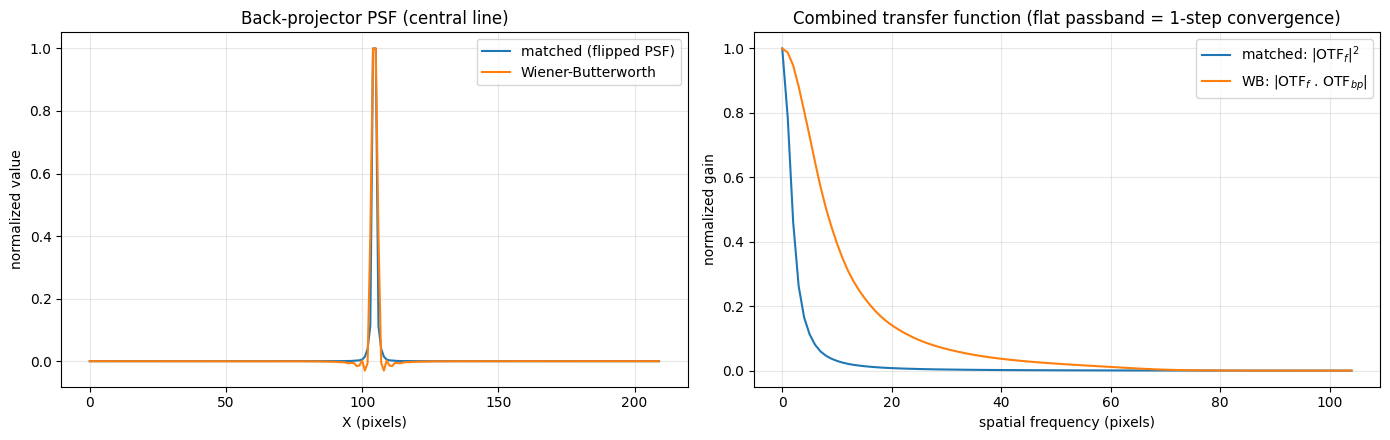

In [3]:
bp_wb = create_backprojector(psf, "wiener-butterworth", alpha=0.05, beta=1.0, n=10)
print(f"WB back projector: shape {bp_wb.shape}, sum {float(bp_wb.sum()):.4f}")

# Matched back projector for comparison: the flipped PSF (conjugate OTF).
psf_n = psf / psf.sum()
flipped = psf_n[::-1, ::-1, ::-1]

# Combined transfer function |FT(f) . FT(b)| along the X axis (central Z, Y).
otf_f = np.fft.fftn(np.fft.ifftshift(psf_n))
otf_wb = np.fft.fftn(np.fft.ifftshift(bp_wb / bp_wb.sum()))
cz, cy = psf.shape[0] // 2, psf.shape[1] // 2


def xprofile(otf):
    """Return the right-half X-axis |OTF| profile, normalized to its DC value."""
    mag = np.fft.fftshift(np.abs(otf))
    line = asnumpy(mag[cz, cy, cz * 0 + psf.shape[2] // 2 :])  # right half along X
    return line / line[0]


matched_combined = xprofile(otf_f * np.conj(otf_f))  # = |OTF_f|^2 (matched)
wb_combined = xprofile(otf_f * otf_wb)  # WB: flat then roll-off
fx = np.arange(matched_combined.size)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
# Spatial central-line profiles (normalized).
ml = asnumpy(flipped[cz, cy])
wl = asnumpy(bp_wb[cz, cy])
axes[0].plot(ml / ml.max(), label="matched (flipped PSF)")
axes[0].plot(wl / wl.max(), label="Wiener-Butterworth")
axes[0].set(
    xlabel="X (pixels)",
    ylabel="normalized value",
    title="Back-projector PSF (central line)",
)
axes[0].legend()
axes[0].grid(alpha=0.3)
# Combined transfer function.
axes[1].plot(fx, matched_combined, label="matched: |OTF$_f$|$^2$")
axes[1].plot(fx, wb_combined, label="WB: |OTF$_f$ . OTF$_{bp}$|")
axes[1].set(
    xlabel="spatial frequency (pixels)",
    ylabel="normalized gain",
    title="Combined transfer function (flat passband = 1-step convergence)",
)
axes[1].legend()
axes[1].grid(alpha=0.3)
fig.tight_layout()
plt.show()

The WB combined transfer function (right) stays close to flat across the passband before rolling off near the resolution cutoff, whereas the matched product $|OTF_f|^2$ is sharply peaked at low frequencies — that flatness is what lets RL converge in one or two steps.

## Track convergence: PSNR, SSIM, and FSC vs iteration

We run matched RL (`backprojector=None`) and WB RL (`backprojector=bp_wb`) through the same `richardson_lucy_iter` call, capturing the estimate at every iteration with an observer. Using the matched result at a high iteration count as a *converged reference*, we measure **PSNR** and **SSIM** of each iterate against it, plus the absolute 3D **FSC resolution** (lateral XY and axial Z, in nm). FSC is a single-image resolution metric that needs no ground truth (FRC is its 2D analog).

In [4]:
fsc_kwargs = dict(
    spacing=voxel_sizes, resample_isotropic=True, exclude_axis_angle=5.0, backend="hist"
)
TRACK_MATCHED, TRACK_WB, REF_ITER = 20, 8, 40


def run_capture(backprojector, n_iter, keep):
    """Run RL once; return {iter: host estimate} for iterations in `keep`."""
    vols = {}

    def observer(restored, i):
        if i in keep:
            vols[i] = asnumpy(restored).copy()

    richardson_lucy_iter(
        image,
        psf,
        n_iter=n_iter,
        implementation="xp",
        observer_fn=observer,
        backprojector=backprojector,
    )
    return vols


# One matched run to the converged reference; reuse its early iterates for tracking.
matched_vols = run_capture(
    None, REF_ITER, set(range(1, TRACK_MATCHED + 1)) | {REF_ITER}
)
wb_vols = run_capture(bp_wb, TRACK_WB, set(range(1, TRACK_WB + 1)))
ref = matched_vols[REF_ITER]


def track(vols, iters):
    """Return per-iteration (PSNR, SSIM, FSC-XY, FSC-Z) arrays vs the reference."""
    ref_dev = ascupy(ref) if USE_GPU else ref
    ps, ss, fxy, fz = [], [], [], []
    for i in iters:
        est = ascupy(vols[i]) if USE_GPU else vols[i]
        ps.append(float(psnr(ref_dev, est, scale_invariant=True)))
        ss.append(float(ssim(ref_dev, est, scale_invariant=True)))
        r = fsc_resolution(est, **fsc_kwargs)
        fxy.append(r["xy"] * 1000)
        fz.append(r["z"] * 1000)
    return map(np.array, (ps, ss, fxy, fz))


m_it = np.arange(1, TRACK_MATCHED + 1)
w_it = np.arange(1, TRACK_WB + 1)
m_ps, m_ss, m_fxy, m_fz = track(matched_vols, m_it)
w_ps, w_ss, w_fxy, w_fz = track(wb_vols, w_it)

match_iter = int(m_it[m_ps >= w_ps[1]][0]) if (m_ps >= w_ps[1]).any() else None
print(f"WB @2: PSNR={w_ps[1]:.2f} dB, SSIM={w_ss[1]:.3f} (vs matched@{REF_ITER})")
print(f"matched first reaches WB@2 PSNR at iteration: {match_iter}")

WB @2: PSNR=39.93 dB, SSIM=0.973 (vs matched@40)
matched first reaches WB@2 PSNR at iteration: 9


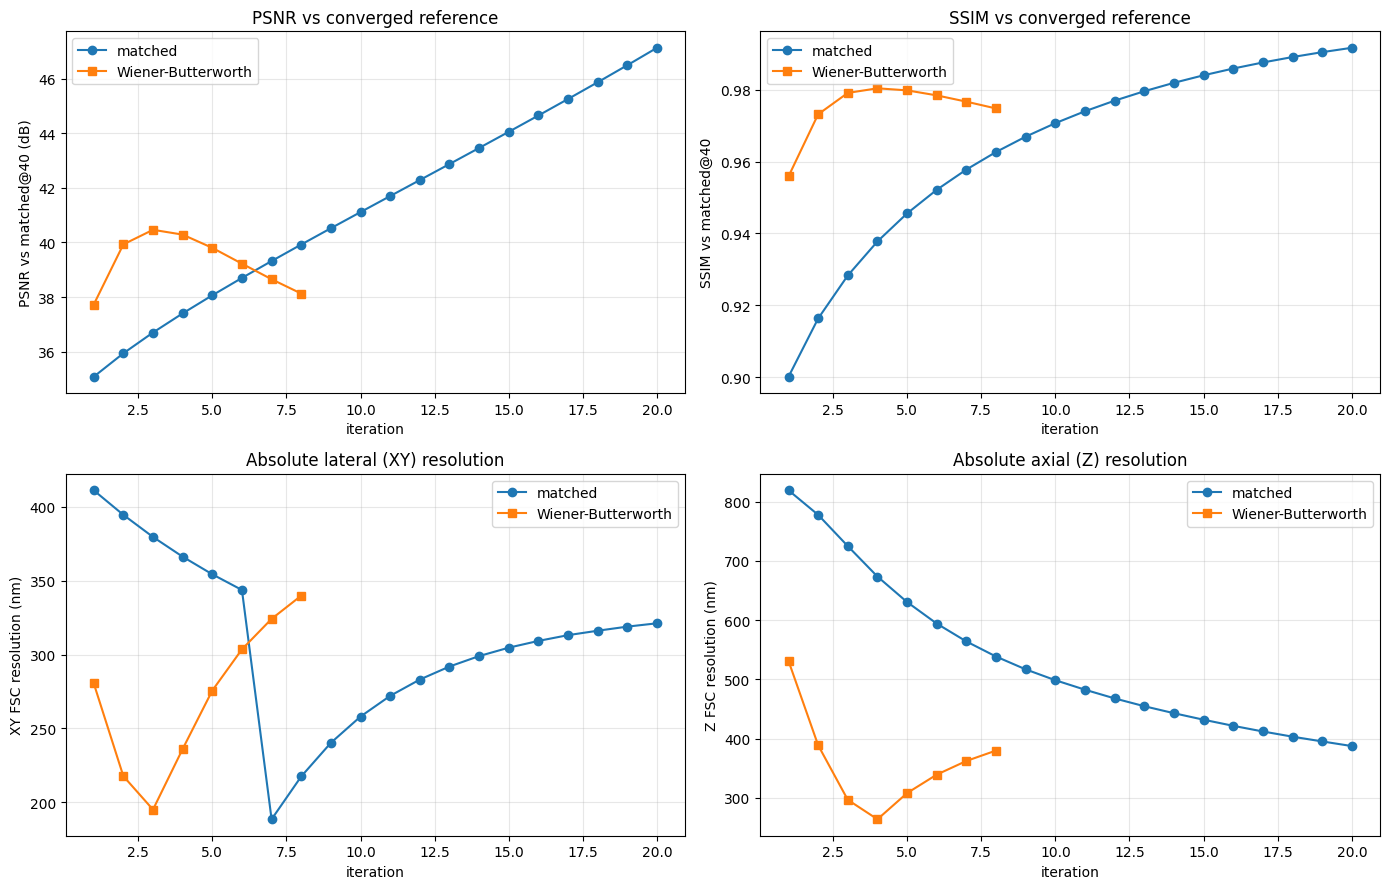

In [5]:
fig, ax = plt.subplots(2, 2, figsize=(14, 9))
ax[0, 0].plot(m_it, m_ps, "o-", label="matched")
ax[0, 0].plot(w_it, w_ps, "s-", label="Wiener-Butterworth")
ax[0, 0].set(
    xlabel="iteration",
    ylabel=f"PSNR vs matched@{REF_ITER} (dB)",
    title="PSNR vs converged reference",
)
ax[0, 1].plot(m_it, m_ss, "o-", label="matched")
ax[0, 1].plot(w_it, w_ss, "s-", label="Wiener-Butterworth")
ax[0, 1].set(
    xlabel="iteration",
    ylabel=f"SSIM vs matched@{REF_ITER}",
    title="SSIM vs converged reference",
)
ax[1, 0].plot(m_it, m_fxy, "o-", label="matched")
ax[1, 0].plot(w_it, w_fxy, "s-", label="Wiener-Butterworth")
ax[1, 0].set(
    xlabel="iteration",
    ylabel="XY FSC resolution (nm)",
    title="Absolute lateral (XY) resolution",
)
ax[1, 1].plot(m_it, m_fz, "o-", label="matched")
ax[1, 1].plot(w_it, w_fz, "s-", label="Wiener-Butterworth")
ax[1, 1].set(
    xlabel="iteration",
    ylabel="Z FSC resolution (nm)",
    title="Absolute axial (Z) resolution",
)
for a in ax.ravel():
    a.legend()
    a.grid(alpha=0.3)
fig.tight_layout()
plt.show()

The WB back projector reaches a near-converged result (PSNR/SSIM vs the matched@40 reference, top row) within **1-2 iterations**, whereas matched RL needs roughly **10 iterations** to reach the same PSNR. In absolute terms (bottom row) WB attains its best FSC resolution by iteration 2-3 — sharper in XY than matched at any tested iteration. Note that WB *degrades* if iterated much further (the Wiener inverse re-amplifies noise), so 1-2 iterations is the sweet spot. Per-iteration FSC is noisier than the reference-based PSNR/SSIM on real data, since the resolution estimate depends on where the FSC curve crosses its threshold.

## Visual comparison: raw vs matched@16 vs WB@2

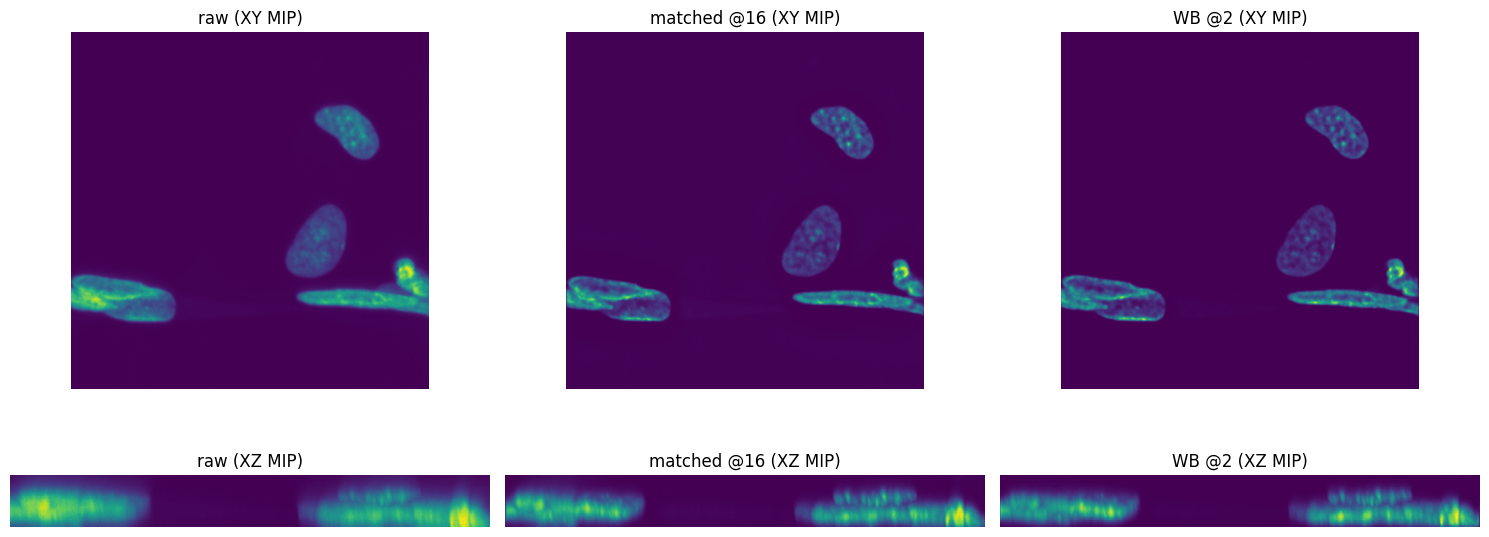

In [6]:
panels = [
    ("raw", asnumpy(image).astype(np.float32)),
    ("matched @16", matched_vols[16]),
    ("WB @2", wb_vols[2]),
]
aspect = voxel_sizes[0] / voxel_sizes[2]  # physical Z/X aspect for the XZ view
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for col, (title, vol) in enumerate(panels):
    axes[0, col].imshow(vol.max(0))
    axes[0, col].set_title(f"{title} (XY MIP)")
    axes[1, col].imshow(vol.max(1), aspect=aspect)
    axes[1, col].set_title(f"{title} (XZ MIP)")
for ax in axes.ravel():
    ax.axis("off")
fig.tight_layout()
plt.show()

## Summary

Toggling an unmatched **Wiener-Butterworth** back projector into `richardson_lucy_iter` via the `backprojector` argument reaches matched-RL-converged resolution in about **1-2 iterations instead of 10-20** — a roughly 10$\times$ reduction in iteration count (and wall-clock time) at equal per-iteration cost.

Practical guidance:

- **Iterations:** 1-2 (occasionally 3). WB is not meant to be run to convergence; further iterations re-amplify noise.
- **`alpha`** (Wiener regularization, default `0.05`): larger values suppress more noise; values that are too small over-amplify high frequencies.
- **`beta=1.0`** (auto) and **`n=10`** (Butterworth order) follow the reference defaults and rarely need tuning.
- The default `backprojector=None` keeps the original matched RL behavior unchanged; the WB path supports circulant deconvolution (no `noncirc` / `mask`).

**Reference:** Guo, M. et al. "Rapid image deconvolution and multiview fusion for optical microscopy." *Nat. Biotechnol.* 38, 1337-1346 (2020).